# Checkpoint 4 — Questão 1: Logística de emergência após eventos climáticos

**Grupo:** _(preencher: nomes e RAs)_
**Turma:** W — Algoritmos e Estruturas de Dados
**Seed do grupo:** `SEED = 1` _(trocar pelo número do grupo antes da entrega)_

Este notebook executa, de ponta a ponta:
1. Geração/carregamento dos dados (grafo da Defesa Civil);
2. Estratégia Greedy (ordem de atendimento);
3. Programação Dinâmica (seleção ótima sob capacidade limitada);
4. Comparação Greedy × DP e contraexemplo;
5. As 3 figuras obrigatórias;
6. Análise de complexidade.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import subprocess
SEED = 1
subprocess.run(['python', '../src/gerar_dados.py', '--seed', str(SEED)], check=True)


[Q1] seed=1: 21 pontos, 40 arestas -> /home/claude/checkpoint4/notebooks/../src/../data/problema1_pontos.csv, /home/claude/checkpoint4/notebooks/../src/../data/problema1_arestas.csv
[Q2] seed=1: 1100 observações -> /home/claude/checkpoint4/notebooks/../src/../data/problema2.csv


CompletedProcess(args=['python', '../src/gerar_dados.py', '--seed', '1'], returncode=0)

## 1. Estruturas de dados e carregamento do grafo

In [2]:
from estruturas import Grafo, Ponto
from analise_q1 import carregar_grafo

g = carregar_grafo()
print(f"Vértices (incluindo centro): {len(g.pontos)}")
n_arestas = sum(len(v) for v in g.adj.values()) // 2
print(f"Arestas: {n_arestas}")


Vértices (incluindo centro): 21
Arestas: 40


As estruturas usadas são explicadas em `src/estruturas.py`:
- `Ponto`: `dataclass(frozen=True)` — registro imutável de cada ponto de atendimento.
- `Grafo.adj`: `dict[int, list[tuple]]` — lista de adjacência, adequada a um grafo esparso.
- `Grafo.dijkstra`: usa um **heap** (`heapq`) como fila de prioridade para extrair sempre o vértice de menor distância provisória em `O(log V)`.


## 2. Estratégia Greedy (Parte B)

In [3]:
from greedy import atendimento_guloso

CAPACIDADE_VEICULO = 30
resultado_greedy = atendimento_guloso(g, origem=0, capacidade=CAPACIDADE_VEICULO)

print("Ordem de prioridade (top 10 por score):")
for pid, score in resultado_greedy.ordem_score[:10]:
    print(f"  ponto {pid:2d} -> score={score:.3f}")

print()
print(f"Selecionados dentro da capacidade: {resultado_greedy.selecionados}")
print(f"Demanda usada: {resultado_greedy.demanda_usada}/{CAPACIDADE_VEICULO}")
print(f"Benefício total (Greedy): {resultado_greedy.beneficio_total}")


Ordem de prioridade (top 10 por score):
  ponto  3 -> score=53.172
  ponto 13 -> score=33.502
  ponto  9 -> score=22.330
  ponto  2 -> score=19.530
  ponto  5 -> score=13.930
  ponto 12 -> score=13.760
  ponto 18 -> score=12.800
  ponto  4 -> score=12.730
  ponto 14 -> score=10.641
  ponto  1 -> score=10.229

Selecionados dentro da capacidade: [3, 13, 9, 2, 5, 12, 4]
Demanda usada: 30/30
Benefício total (Greedy): 531


A justificativa completa da função de prioridade (por que a decisão é localmente vantajosa) está na docstring de `src/greedy.py`.

## 3. Programação Dinâmica (Parte C)

In [4]:
from dynamic_programming import selecao_otima_dp

pontos_candidatos = [p for pid, p in g.pontos.items() if pid != 0]
resultado_dp = selecao_otima_dp(pontos_candidatos, CAPACIDADE_VEICULO)

print(f"Selecionados (ótimo): {resultado_dp.selecionados}")
print(f"Demanda usada: {resultado_dp.demanda_usada}/{CAPACIDADE_VEICULO}")
print(f"Benefício ótimo (DP): {resultado_dp.beneficio_otimo}")


Selecionados (ótimo): [1, 2, 3, 4, 5, 6, 9, 13]
Demanda usada: 30/30
Benefício ótimo (DP): 575


**Modelagem (resumo — detalhes completos na docstring de `dynamic_programming.py`):**

- **Estado:** `DP[i][c]` = maior benefício considerando os `i` primeiros pontos candidatos e capacidade `c`.
- **Decisão:** atender ou não o ponto `i`.
- **Caso-base:** `DP[0][c] = 0` e `DP[i][0] = 0`.
- **Recorrência:** `DP[i][c] = max(DP[i-1][c], DP[i-1][c-demanda_i] + beneficio_i)` (se `demanda_i <= c`).
- **Reconstrução:** back-tracking na tabela, de `DP[n][C]` até `DP[0][*]`, comparando `DP[i][c]` com `DP[i-1][c]`.


## 4. Comparação Greedy × DP e contraexemplo (Parte D)

In [5]:
gap = resultado_dp.beneficio_otimo - resultado_greedy.beneficio_total
print(f"Greedy: {resultado_greedy.beneficio_total}   DP: {resultado_dp.beneficio_otimo}   Gap: {gap}")
if gap > 0:
    print("-> Neste conjunto de dados, a DP encontrou uma solução estritamente melhor que o Greedy.")
else:
    print("-> Neste conjunto de dados, o Greedy também atingiu o ótimo (isso PODE acontecer, mas não é garantido).")


Greedy: 531   DP: 575   Gap: 44
-> Neste conjunto de dados, a DP encontrou uma solução estritamente melhor que o Greedy.


In [6]:
from dynamic_programming import contraexemplo_greedy_vs_dp

exemplo = contraexemplo_greedy_vs_dp()
print("Contraexemplo mínimo (3 pontos, capacidade 10):")
print(exemplo)
assert exemplo['dp_beneficio'] > exemplo['greedy_beneficio'], "Este contraexemplo deve mostrar Greedy subótimo"
print()
print("Por que o Greedy falha aqui: ele escolhe o ponto de maior razão benefício/demanda")
print("primeiro (A: 11/6=1.83), mas isso consome capacidade demais e impede escolher B+C")
print("juntos (5+5=10, beneficio 8+8=16), que é estritamente melhor que só A (beneficio 11).")


Contraexemplo mínimo (3 pontos, capacidade 10):
{'capacidade': 10, 'greedy_escolhidos': [1], 'greedy_beneficio': 11, 'dp_escolhidos': [2, 3], 'dp_beneficio': 16}

Por que o Greedy falha aqui: ele escolhe o ponto de maior razão benefício/demanda
primeiro (A: 11/6=1.83), mas isso consome capacidade demais e impede escolher B+C
juntos (5+5=10, beneficio 8+8=16), que é estritamente melhor que só A (beneficio 11).


## 5. Figuras obrigatórias

/home/claude/checkpoint4/src/analise_q1.py:93: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter([p.x], [p.y], c=cor, marker=marcador, s=150, edgecolor="black", zorder=2)


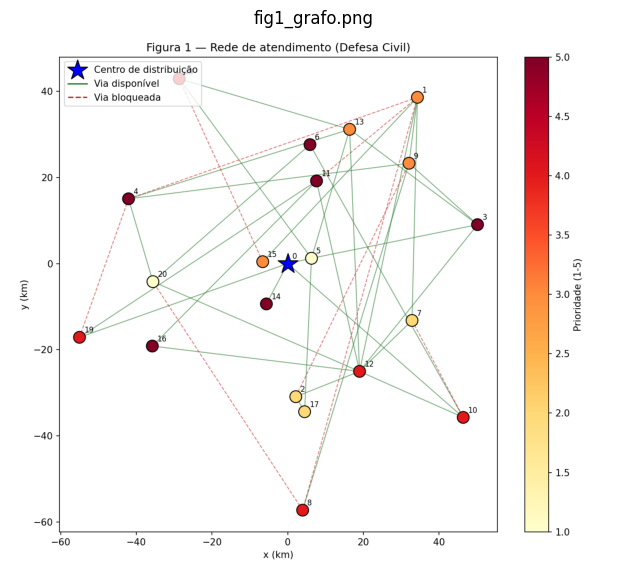

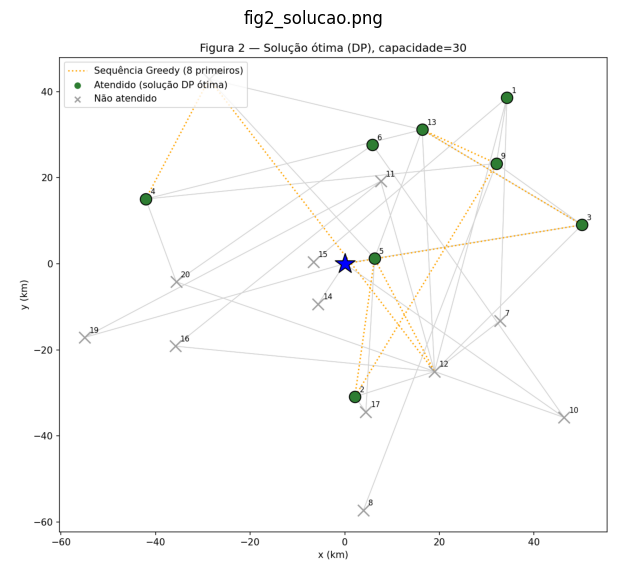

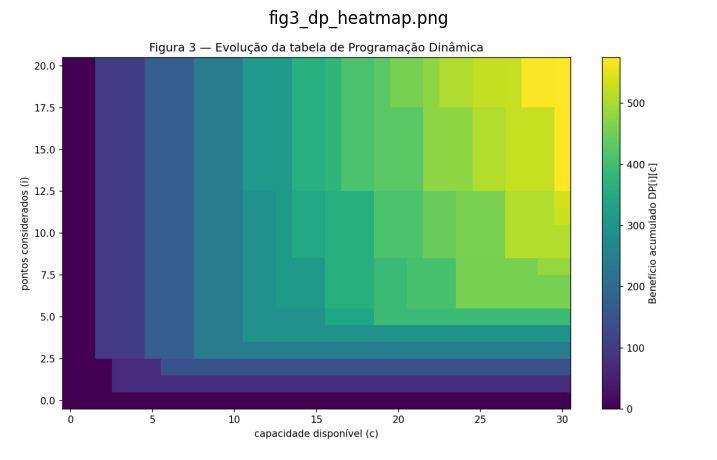

In [7]:
from analise_q1 import fig1_grafo, fig2_solucao, fig3_dp_heatmap
import matplotlib.pyplot as plt

fig1_grafo(g)
fig2_solucao(g, resultado_dp.selecionados, resultado_greedy.ordem_score)
fig3_dp_heatmap(resultado_dp.tabela)

from PIL import Image
for nome in ["fig1_grafo.png", "fig2_solucao.png", "fig3_dp_heatmap.png"]:
    caminho = f"../figures/questao1/{nome}"
    img = Image.open(caminho)
    plt.figure(figsize=(9, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title(nome)
    plt.show()


## 6. Complexidade (resumo)

Ver detalhamento completo em `docs/analise_complexidade.md`. Resumo:

| Algoritmo | Tempo | Espaço |
|---|---|---|
| Dijkstra | `O((V+E) log V)` | `O(V+E)` |
| Greedy (Parte B) | `O((V+E) log V + N log N)` | `O(V+E+N)` |
| Programação Dinâmica (Parte C) | `O(N·C)` | `O(N·C)` |

Onde `V` = vértices, `E` = arestas, `N` = pontos candidatos, `C` = capacidade do veículo.
